# Vision Transformers — Attention Instead of Convolution

**Notebook 05 · Classification** · runs on CUDA, Apple MPS, or CPU

---

## What this notebook establishes

Notebook 04 fine-tuned a ResNet-50 on Oxford-IIIT Pet. This one fine-tunes a **ViT-B/16** on the
identical dataset, split and augmentation pipeline, so the two results are directly comparable — and
then opens the model up to look at *where it is actually looking*, which is the thing a CNN cannot
easily tell you.

Along the way, multi-head self-attention is implemented from scratch and **verified numerically
against PyTorch's fused `scaled_dot_product_attention`**, in the same spirit as notebook 01's
from-scratch convolution.

## The core idea: an image is a sequence of patches

A ViT has no convolutions. It cuts the image into non-overlapping patches, projects each to a vector,
and hands the resulting sequence to a standard Transformer encoder.

For a $224 \times 224$ image with $16 \times 16$ patches:

$$N = \frac{224}{16} \times \frac{224}{16} = 14 \times 14 = 196 \text{ patches}$$

Each patch is flattened ($16 \cdot 16 \cdot 3 = 768$ values) and linearly projected to the model
dimension $D = 768$. Implementation detail worth knowing: this "cut into patches, flatten, project"
operation is **exactly a `Conv2d(3, 768, kernel_size=16, stride=16)`** — which is how torchvision
implements it. The only convolution in a Vision Transformer is the one that stops it being an image.

A learned `[CLS]` token is prepended and learned positional embeddings are added, because attention
is permutation-equivariant and would otherwise have no idea where any patch came from:

$$\mathbf{z}_0 = [\,\mathbf{x}_{\text{cls}};\; \mathbf{x}^1_p\mathbf{E};\; \dots;\; \mathbf{x}^N_p\mathbf{E}\,] + \mathbf{E}_{\text{pos}},
\qquad \mathbf{E} \in \mathbb{R}^{(P^2 C)\times D}$$

## Self-attention

Every token attends to every other token, from the very first layer:

$$\text{Attention}(Q,K,V) = \operatorname{softmax}\!\left(\frac{QK^{\!\top}}{\sqrt{d_k}}\right)V$$

The $\sqrt{d_k}$ is not cosmetic. For $q, k$ with unit-variance independent components,
$\operatorname{Var}(q\cdot k) = d_k$; without rescaling, the logits grow with dimension, softmax
saturates, and gradients vanish. Multiple heads run this in parallel on projected subspaces:

$$\text{MHSA}(X) = [\text{head}_1;\dots;\text{head}_h]\,W^O, \qquad
\text{head}_i = \text{Attention}(XW_i^Q, XW_i^K, XW_i^V)$$

```
   image (3,224,224)
        │
   PatchEmbed: Conv2d(3→768, k=16, s=16)  ->  (768, 14, 14) -> flatten -> (196, 768)
        │
   prepend [CLS] -> (197, 768)   +  learned positional embedding
        │
   ┌────────────────── x12 encoder blocks ──────────────────┐
   │   z = z + MHSA(LayerNorm(z))        <- pre-norm         │
   │   z = z + MLP(LayerNorm(z))         <- GELU, 4x expand  │
   └─────────────────────────────────────────────────────────┘
        │
   LayerNorm -> take [CLS] row -> Linear 768→37
```

**Pre-norm, not post-norm.** LayerNorm sits *inside* the residual branch. This keeps a clean identity
path from input to output, which is what makes deep Transformers trainable without the elaborate
warmup schedules the original post-norm formulation required.

## The trade-off, stated honestly

| | CNN (ResNet) | ViT |
| --- | --- | --- |
| Inductive bias | Locality + translation equivariance, built in | Almost none; must be learned |
| Receptive field at layer 1 | 3×3 | global |
| Cost in sequence length | linear | **quadratic** — $O(N^2)$ attention |
| Small-data behaviour | trains acceptably | poor without pretraining |
| Large-data behaviour | saturates earlier | keeps improving |

The missing inductive bias is the whole story. A CNN is *told* that nearby pixels are related; a ViT
must discover it from data, which costs a great deal of data. On ImageNet-1k alone, ViT
underperforms a comparable ResNet. Pretrained on ImageNet-21k or larger, it wins. **This is why the
notebook fine-tunes rather than trains from scratch** — training a ViT from scratch on 3,680 pet
photographs would produce a spectacularly bad model, and the honest lesson is knowing that in
advance rather than discovering it after a wasted GPU-day.

## Provenance

New material. The repository had no attention-based vision model, and no notebook that inspected what
a model attends to.

---

# 2. Setup & Reproducibility

Same preamble as the rest of the folder; see notebook 02 for the mixed-precision reasoning.

In [1]:
%pip install onnxruntime onnxscript albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 135.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 369.4/369.4 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 138.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 583.5/583.5 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 62.9 MB/s eta 0:00:00


In [ ]:
from __future__ import annotations

import json
import os
import platform
import random
import tempfile
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Final

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from albumentations.pytorch import ToTensorV2
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.models import ViT_B_16_Weights, vit_b_16
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
cv2.setNumThreads(0)

SEED: Final[int] = 42
# Written under the OS temp directory rather than a project-relative folder: this
# repo assumes ephemeral execution (e.g. Google Colab), so nothing should persist
# in the working directory between runs.
_TMP: Final[Path] = Path(tempfile.gettempdir())
DATA_ROOT: Final[Path] = _TMP / "vision-data"
ARTIFACT_DIR: Final[Path] = _TMP / "vision-artifacts" / "05_vision_transformer"

IMAGENET_MEAN: Final[tuple[float, float, float]] = (0.485, 0.456, 0.406)
IMAGENET_STD: Final[tuple[float, float, float]] = (0.229, 0.224, 0.225)
IMAGE_SIZE: Final[int] = 224
PATCH_SIZE: Final[int] = 16
EMBED_DIM: Final[int] = 768
NUM_HEADS: Final[int] = 12
NUM_LAYERS: Final[int] = 12
NUM_CLASSES: Final[int] = 37
GRID_SIZE: Final[int] = IMAGE_SIZE // PATCH_SIZE       # 14
NUM_PATCHES: Final[int] = GRID_SIZE * GRID_SIZE        # 196

# Same subset sizes as notebook 04, deliberately -- the ViT-vs-ResNet comparison only
# means anything if both see identical data. Fast default: 10 per class. Raise toward
# 1_480 / 740 (40 / 20 per class) for a stronger signal, or None for the full split.
TRAIN_SUBSET_SIZE: Final[int | None] = 370   # 10 per class
TEST_SUBSET_SIZE: Final[int | None] = 370    # 10 per class

# Set DETERMINISTIC=0 to let cuDNN autotune. On a CUDA GPU this speeds up every
# convolution substantially; it costs exact run-to-run reproducibility.
DETERMINISTIC: Final[bool] = os.getenv("DETERMINISTIC", "1") == "1"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int = SEED, *, deterministic: bool = DETERMINISTIC) -> None:
    """Seed every RNG that can influence a training run.

    Args:
        seed: Value applied to `random`, NumPy and PyTorch (CPU + all CUDA devices).
        deterministic: Force cuDNN's deterministic algorithm set and disable its
            autotuner. Both affect **convolutions only**, so on a CUDA GPU this is the
            first thing to check when a conv-heavy model seems disproportionately slow.
            Defaults to the `DETERMINISTIC` environment variable (on unless set to 0).
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    """Return the best available accelerator, preferring CUDA, then Apple MPS, then CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


@dataclass(frozen=True)
class Runtime:
    """Hardware-dependent execution policy, resolved once and passed down.

    Attributes:
        device: Target device for tensors and modules.
        amp_enabled: Whether `torch.autocast` should be active.
        amp_dtype: Low-precision dtype used under autocast.
        needs_grad_scaler: True only for float16, where gradient underflow is a real risk.
    """

    device: torch.device
    amp_enabled: bool
    amp_dtype: torch.dtype
    needs_grad_scaler: bool

    @classmethod
    def resolve(cls, device: torch.device) -> "Runtime":
        """Pick the mixed-precision policy that is actually beneficial on `device`."""
        if device.type == "cuda":
            use_bf16 = torch.cuda.is_bf16_supported()
            dtype = torch.bfloat16 if use_bf16 else torch.float16
            return cls(device, True, dtype, needs_grad_scaler=not use_bf16)
        if device.type == "cpu":
            return cls(device, True, torch.bfloat16, needs_grad_scaler=False)
        return cls(device, False, torch.float32, needs_grad_scaler=False)


def dataloader_kwargs(device: torch.device) -> dict[str, object]:
    """DataLoader settings tuned per backend; workers stay off outside CUDA on macOS."""
    if device.type == "cuda":
        # Cap at the real CPU count: hardcoding 4 oversubscribes a 2-vCPU host (Colab
        # free tier), and CPU-side augmentation starves the GPU when it thrashes.
        workers = min(4, os.cpu_count() or 2)
        return {
            "num_workers": workers,
            "pin_memory": True,
            "persistent_workers": workers > 0,  # invalid when workers == 0
        }
    return {"num_workers": 0, "pin_memory": False}


seed_everything()
DEVICE: Final[torch.device] = get_device()
RUNTIME: Final[Runtime] = Runtime.resolve(DEVICE)

_rows = [
    ("python", platform.python_version()),
    ("platform", f"{platform.system()} {platform.machine()}"),
    ("torch", torch.__version__),
    ("torchvision", torchvision.__version__),
    ("albumentations", A.__version__),
    ("onnxruntime", ort.__version__),
    ("device", str(RUNTIME.device)),
    ("autocast", f"{RUNTIME.amp_dtype}" if RUNTIME.amp_enabled else "disabled"),
    ("cpu count", str(os.cpu_count())),
    ("seed", str(SEED)),
    ("deterministic", f"{DETERMINISTIC}" + ("  <- slows convolutions" if DETERMINISTIC else "")),
]
print(f"{'component':<16}{'value'}")
print("-" * 46)
for _k, _v in _rows:
    print(f"{_k:<16}{_v}")
print(f"\nViT-B/16 token budget: {NUM_PATCHES} patches + 1 [CLS] = {NUM_PATCHES + 1} tokens")
print(f"attention matrix per head per layer: {NUM_PATCHES + 1} x {NUM_PATCHES + 1} "
      f"= {(NUM_PATCHES + 1) ** 2:,} entries")

---

# 3. Data Pipeline

Identical to notebook 04 — same dataset, same split, same transforms — because a comparison between
two architectures is only meaningful if everything else is held fixed.

One ViT-specific constraint: **input size is not free.** The positional embedding table has one row
per patch position, learned at $14 \times 14$. Feeding a $256\times256$ image produces 256 patches
and the table no longer matches. It *can* be interpolated (torchvision provides
`interpolate_embeddings` for exactly this), but that is a deliberate operation, not something that
happens automatically. A CNN would simply have accepted the larger input. This is the first place the
"transformers are more flexible" intuition turns out to be backwards.

In [ ]:
def build_transforms(train: bool, size: int = IMAGE_SIZE) -> A.Compose:
    """Compose the augmentation pipeline for one split.

    Args:
        train: If True, apply stochastic augmentation; validation is deterministic.
        size: Target square edge length. Must match the positional-embedding grid.

    Returns:
        An Albumentations pipeline mapping an HxWx3 uint8 array to a (3, size, size) tensor.
    """
    normalise = [A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]

    if not train:
        return A.Compose(
            [
                A.SmallestMaxSize(max_size=int(size * 256 / 224)),
                A.CenterCrop(height=size, width=size),
                *normalise,
            ]
        )

    return A.Compose(
        [
            A.RandomResizedCrop(size=(size, size), scale=(0.6, 1.0), ratio=(0.8, 1.25)),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=15, val_shift_limit=10, p=0.3),
            *normalise,
        ]
    )


class OxfordPetDataset(Dataset):
    """Oxford-IIIT Pet breed classification with an Albumentations pipeline.

    Args:
        root: Dataset root directory.
        split: `"trainval"` or `"test"`.
        transform: Pipeline applied to every sample on access.
        indices: Optional subset of indices; None uses every image in the split.
    """

    def __init__(
        self,
        root: Path,
        split: str,
        transform: A.Compose,
        indices: np.ndarray | None = None,
    ) -> None:
        self.base = datasets.OxfordIIITPet(
            root=root, split=split, target_types="category", download=True
        )
        self.transform = transform
        self.indices = np.arange(len(self.base)) if indices is None else indices

    def __len__(self) -> int:
        return len(self.indices)

    @property
    def classes(self) -> list[str]:
        """Breed names, ordered by label index."""
        return self.base.classes

    def raw_image(self, index: int) -> np.ndarray:
        """Return the undecorated RGB array, for attention overlays in section 6."""
        image, _ = self.base[int(self.indices[index])]
        return np.asarray(image.convert("RGB"))

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        """Return one (image, label) pair.

        Shape:
            image: (3, IMAGE_SIZE, IMAGE_SIZE) float32, ImageNet-normalised.
            label: () int64.
        """
        image, label = self.base[int(self.indices[index])]
        array = np.asarray(image.convert("RGB"))
        return self.transform(image=array)["image"], torch.tensor(label, dtype=torch.long)


def stratified_subset(labels: np.ndarray, size: int, seed: int = SEED) -> np.ndarray:
    """Draw a class-balanced subset of indices, at least one per class."""
    rng = np.random.default_rng(seed)
    per_class = max(size // NUM_CLASSES, 1)
    selected = [
        rng.choice(
            np.flatnonzero(labels == class_index),
            size=min(per_class, int((labels == class_index).sum())),
            replace=False,
        )
        for class_index in range(NUM_CLASSES)
    ]
    indices = np.concatenate(selected)
    rng.shuffle(indices)
    return indices


_probe_train = datasets.OxfordIIITPet(root=DATA_ROOT, split="trainval", download=True)
_probe_test = datasets.OxfordIIITPet(root=DATA_ROOT, split="test", download=True)
train_indices = (
    stratified_subset(np.array(_probe_train._labels), TRAIN_SUBSET_SIZE)
    if TRAIN_SUBSET_SIZE else None
)
test_indices = (
    stratified_subset(np.array(_probe_test._labels), TEST_SUBSET_SIZE)
    if TEST_SUBSET_SIZE else None
)

train_dataset = OxfordPetDataset(DATA_ROOT, "trainval", build_transforms(True), train_indices)
test_dataset = OxfordPetDataset(DATA_ROOT, "test", build_transforms(False), test_indices)
CLASS_NAMES: Final[tuple[str, ...]] = tuple(train_dataset.classes)

print(f"train images : {len(train_dataset):,}")
print(f"test images  : {len(test_dataset):,}")
print(f"classes      : {len(CLASS_NAMES)}")

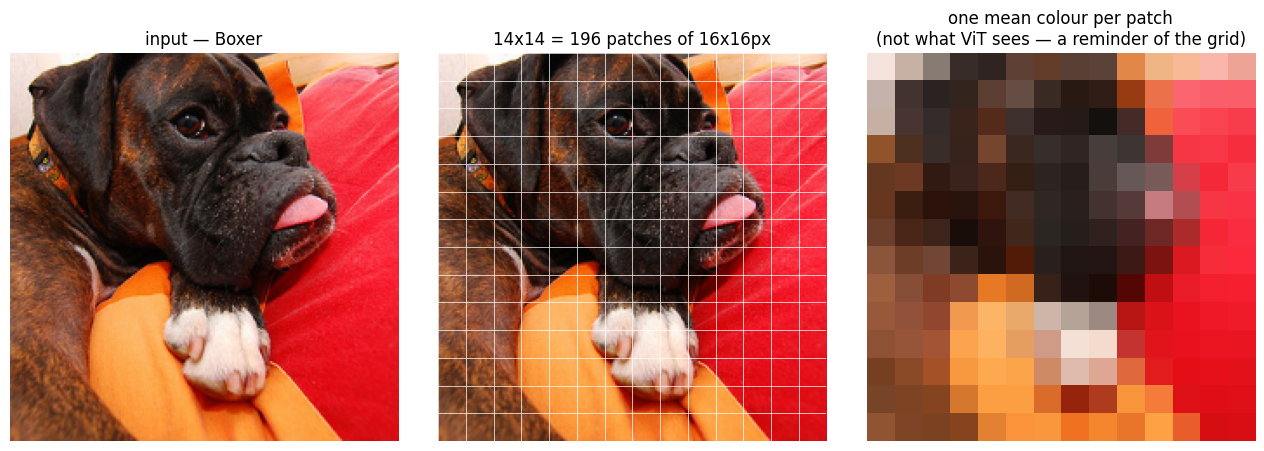

In [4]:
def denormalise(tensor: torch.Tensor) -> np.ndarray:
    """Invert ImageNet normalisation so a tensor can be displayed.

    Args:
        tensor: (3, H, W) normalised image.

    Returns:
        (H, W, 3) float array clipped to [0, 1].
    """
    mean = np.array(IMAGENET_MEAN).reshape(-1, 1, 1)
    std = np.array(IMAGENET_STD).reshape(-1, 1, 1)
    image = tensor.detach().cpu().numpy() * std + mean
    return np.clip(image.transpose(1, 2, 0), 0.0, 1.0)


# Show the patch grid the model actually sees -- the 14x14 tokenisation is the
# whole representation, and it is coarser than most people picture.
sample_image, sample_label = test_dataset[0]
displayed = denormalise(sample_image)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
axes[0].imshow(displayed)
axes[0].set_title(f"input — {CLASS_NAMES[int(sample_label)]}")
axes[0].axis("off")

axes[1].imshow(displayed)
for position in range(0, IMAGE_SIZE + 1, PATCH_SIZE):
    axes[1].axhline(position - 0.5, color="white", lw=0.5)
    axes[1].axvline(position - 0.5, color="white", lw=0.5)
axes[1].set_title(f"{GRID_SIZE}x{GRID_SIZE} = {NUM_PATCHES} patches of {PATCH_SIZE}x{PATCH_SIZE}px")
axes[1].axis("off")

# Each patch reduced to its mean colour: an upper bound on what a single token carries.
patches = displayed.reshape(GRID_SIZE, PATCH_SIZE, GRID_SIZE, PATCH_SIZE, 3).mean(axis=(1, 3))
axes[2].imshow(patches)
axes[2].set_title("one mean colour per patch\n(not what ViT sees — a reminder of the grid)")
axes[2].axis("off")

fig.tight_layout()
plt.show()

---

# 4. Modular Architecture

Two things happen here. First, multi-head self-attention is implemented from scratch and checked
against PyTorch's fused kernel — the same "build it, then verify it" pattern as notebook 01's
convolution. Second, the pretrained ViT-B/16 is wrapped with a new 37-way head.

### Why the from-scratch version is worth writing

`F.scaled_dot_product_attention` dispatches to FlashAttention or a memory-efficient kernel and never
materialises the $N \times N$ attention matrix. That is exactly what makes it fast, and exactly why
it cannot hand you the attention weights for visualisation. Understanding what the fused kernel is
computing is what makes section 6's rollout interpretable rather than magical.

In [5]:
class MultiHeadSelfAttention(nn.Module):
    """Multi-head self-attention, written out explicitly.

    Materialises the full attention matrix, which is the point: it is inspectable.
    Production code should prefer `F.scaled_dot_product_attention`, which fuses the
    same computation and never allocates the (N, N) matrix.

    Args:
        embed_dim: Model dimension D.
        num_heads: Number of attention heads. Must divide `embed_dim`.
        dropout: Probability applied to the attention weights.

    Raises:
        ValueError: If `embed_dim` is not divisible by `num_heads`.
    """

    def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.0) -> None:
        super().__init__()
        if embed_dim % num_heads != 0:
            raise ValueError(f"embed_dim {embed_dim} not divisible by num_heads {num_heads}")

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        # 1/sqrt(d_k): without it, logit variance grows with head_dim, softmax saturates,
        # and the gradient through it vanishes.
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=True)
        self.projection = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Apply self-attention and also return the attention weights.

        Args:
            x: Token sequence.

        Returns:
            Tuple of (output, attention weights averaged over heads).

        Shape:
            x: (N, L, D)
            output: (N, L, D)
            attention: (N, L, L)
        """
        batch, length, _ = x.shape

        qkv = self.qkv(x).reshape(batch, length, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)          # (3, N, heads, L, head_dim)
        query, key, value = qkv[0], qkv[1], qkv[2]

        logits = (query @ key.transpose(-2, -1)) * self.scale   # (N, heads, L, L)
        attention = logits.softmax(dim=-1)
        out = self.dropout(attention) @ value                    # (N, heads, L, head_dim)

        out = out.transpose(1, 2).reshape(batch, length, self.embed_dim)
        return self.projection(out), attention.mean(dim=1)

### The check: from-scratch attention == PyTorch's fused kernel

Both implementations are given the same weights, so any disagreement is an implementation bug rather
than an initialisation difference. Tolerance is loose enough to permit different summation orders and
tight enough to catch a missing scale factor or a transposed operand.

In [6]:
ATTENTION_ATOL: Final[float] = 1e-5

seed_everything()
_probe_length, _probe_batch = 20, 2
_reference = MultiHeadSelfAttention(EMBED_DIM, NUM_HEADS).eval()
_x = torch.randn(_probe_batch, _probe_length, EMBED_DIM)

with torch.no_grad():
    _ours, _attention = _reference(_x)

    # Same weights, PyTorch's fused path.
    _qkv = _reference.qkv(_x).reshape(
        _probe_batch, _probe_length, 3, NUM_HEADS, EMBED_DIM // NUM_HEADS
    ).permute(2, 0, 3, 1, 4)
    _fused = F.scaled_dot_product_attention(_qkv[0], _qkv[1], _qkv[2])
    _fused = _reference.projection(
        _fused.transpose(1, 2).reshape(_probe_batch, _probe_length, EMBED_DIM)
    )

torch.testing.assert_close(_ours, _fused, atol=ATTENTION_ATOL, rtol=ATTENTION_ATOL)

_row_sums = _attention.sum(dim=-1)
torch.testing.assert_close(_row_sums, torch.ones_like(_row_sums), atol=1e-5, rtol=1e-5)

print(f"from-scratch MHSA matches F.scaled_dot_product_attention "
      f"(max |Δ| = {(_ours - _fused).abs().max():.2e})")
print(f"attention rows sum to 1 — it is a valid probability distribution over {_probe_length} tokens")
print(f"attention tensor shape: {tuple(_attention.shape)}")
del _reference, _x, _ours, _fused, _attention

from-scratch MHSA matches F.scaled_dot_product_attention (max |Δ| = 1.04e-07)
attention rows sum to 1 — it is a valid probability distribution over 20 tokens
attention tensor shape: (2, 20, 20)


### The pretrained model

torchvision's `vit_b_16` with ImageNet-1k weights. The classification head is replaced; everything
else is inherited.

**Layer-wise learning-rate decay** matters more for ViTs than for CNNs. Transformers are notoriously
sensitive to learning rate during fine-tuning — too high and the pretrained attention patterns
collapse within a few hundred steps. The rates here are an order of magnitude below notebook 04's,
which is the standard adjustment and not a typo.

In [7]:
@dataclass(frozen=True)
class ViTConfig:
    """Fine-tuning strategy for the Vision Transformer.

    Attributes:
        pretrained: Load ImageNet weights. False trains from scratch and, on this dataset
            size, is expected to fail -- see the discussion in section 1.
        freeze_backbone: Train only the classification head (linear probe).
        dropout: Probability applied before the final linear layer.
        head_lr: Learning rate for the new head.
        backbone_lr: Learning rate for the LAST encoder block.
        layer_decay: Multiplier applied per block toward the input, so early blocks move
            slowest. This is the ViT equivalent of notebook 04's stage-wise decay.
    """

    pretrained: bool = True
    freeze_backbone: bool = False
    dropout: float = 0.1
    head_lr: float = 1e-3
    backbone_lr: float = 1e-4
    layer_decay: float = 0.75


class ViTClassifier(nn.Module):
    """ViT-B/16 with a replaced classification head.

    Args:
        config: Strategy definition.
        num_classes: Output logit count.
    """

    def __init__(self, config: ViTConfig, num_classes: int = NUM_CLASSES) -> None:
        super().__init__()
        self.config = config

        weights = ViT_B_16_Weights.IMAGENET1K_V1 if config.pretrained else None
        self.backbone = vit_b_16(weights=weights)

        in_features = self.backbone.heads.head.in_features
        self.backbone.heads = nn.Sequential(
            nn.Dropout(config.dropout),
            nn.Linear(in_features, num_classes),
        )

        if config.freeze_backbone:
            for name, parameter in self.backbone.named_parameters():
                if not name.startswith("heads"):
                    parameter.requires_grad = False

    def train(self, mode: bool = True) -> "ViTClassifier":
        """Set training mode. LayerNorm has no running statistics, so unlike notebook 04's
        BatchNorm backbone there is nothing that drifts when frozen -- but the encoder is
        still forced to eval() so dropout inside it stays off.
        """
        super().train(mode)
        if self.config.freeze_backbone:
            self.backbone.encoder.eval()
            self.backbone.heads.train(mode)
        return self

    def parameter_groups(self) -> list[dict[str, object]]:
        """Build optimiser groups with block-wise decayed learning rates.

        Returns:
            Parameter groups suitable for `torch.optim.AdamW`.
        """
        groups: list[dict[str, object]] = [
            {
                "params": list(self.backbone.heads.parameters()),
                "lr": self.config.head_lr,
                "name": "head",
            }
        ]
        if self.config.freeze_backbone:
            return groups

        blocks = list(self.backbone.encoder.layers)
        for depth, block in enumerate(reversed(blocks)):
            groups.append({
                "params": list(block.parameters()),
                "lr": self.config.backbone_lr * (self.config.layer_decay ** depth),
                "name": f"block_{len(blocks) - 1 - depth}",
            })

        # Patch embedding, class token, positional embedding and the final norm: the most
        # generic parameters in the model, so the slowest rate of all.
        stem_parameters = (
            list(self.backbone.conv_proj.parameters())
            + [self.backbone.class_token]
            + list(self.backbone.encoder.ln.parameters())
            + [self.backbone.encoder.pos_embedding]
        )
        groups.append({
            "params": stem_parameters,
            "lr": self.config.backbone_lr * (self.config.layer_decay ** len(blocks)),
            "name": "patch_embed+pos",
        })
        return groups

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Map a batch of images to class logits.

        Shape:
            x: (N, 3, 224, 224)
            output: (N, num_classes)
        """
        return self.backbone(x)


def count_parameters(model: nn.Module, trainable_only: bool = True) -> int:
    """Count parameters, optionally restricted to those requiring gradients."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad or not trainable_only)


seed_everything()
_model = ViTClassifier(ViTConfig()).to(DEVICE).eval()
_probe = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
with torch.no_grad():
    _out = _model(_probe)
assert _out.shape == (2, NUM_CLASSES), f"unexpected output shape {tuple(_out.shape)}"

print(f"ViT-B/16: {count_parameters(_model, False):,} total, "
      f"{count_parameters(_model):,} trainable")
print(f"forward : {tuple(_probe.shape)} -> {tuple(_out.shape)}")
print(f"\n{'group':<20}{'lr':>12}{'params':>14}")
print("-" * 46)
for group in _model.parameter_groups():
    n = sum(p.numel() for p in group["params"])
    print(f"{group['name']:<20}{group['lr']:>12.2e}{n:>14,}")
del _model

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 311MB/s]


ViT-B/16: 85,827,109 total, 85,827,109 trainable
forward : (2, 3, 224, 224) -> (2, 37)

group                         lr        params
----------------------------------------------
head                    1.00e-03        28,453
block_11                1.00e-04     7,087,872
block_10                7.50e-05     7,087,872
block_9                 5.63e-05     7,087,872
block_8                 4.22e-05     7,087,872
block_7                 3.16e-05     7,087,872
block_6                 2.37e-05     7,087,872
block_5                 1.78e-05     7,087,872
block_4                 1.33e-05     7,087,872
block_3                 1.00e-05     7,087,872
block_2                 7.51e-06     7,087,872
block_1                 5.63e-06     7,087,872
block_0                 4.22e-06     7,087,872
patch_embed+pos         3.17e-06       744,192


---

# 5. Production Training Loop

Same structure as notebooks 03 and 04. Two ViT-specific adjustments:

**Gradient clipping matters more here.** Transformer training is prone to loss spikes, and a single
bad batch can knock a fine-tune off course permanently. The clip threshold stays at 1.0 but is doing
real work rather than acting as insurance.

**No weight decay on norms, biases, or the positional embedding.** Decaying a LayerNorm gain toward
zero shrinks the activations it is meant to normalise; decaying the positional embedding erases
learned spatial structure. Excluding one-dimensional parameters from weight decay is standard for
Transformers and is one of the more common omissions in hand-rolled fine-tuning scripts.

In [ ]:
@dataclass(frozen=True)
class TrainConfig:
    """Optimisation hyper-parameters.

    Attributes:
        epochs: Total passes over the training set.
        batch_size: Samples per optimiser step. ViT-B/16 activations are large; 16 fits
            comfortably in 8 GB, raise it if you have headroom.
        weight_decay: Decoupled AdamW penalty, applied only to 2-D+ parameters.
        warmup_epochs: Epochs spent ramping every group's LR up.
        warmup_start_factor: Initial LR as a fraction of the target.
        min_lr: Cosine floor.
        grad_clip_norm: Maximum global gradient L2 norm.
        label_smoothing: Cross-entropy target smoothing epsilon.
    """

    # Fast default for reference use. 3 epochs is enough for a pretrained ViT to
    # converge on 37 classes; production runs use 6-10.
    epochs: int = 1
    batch_size: int = 16
    weight_decay: float = 0.05
    warmup_epochs: int = 0
    warmup_start_factor: float = 0.1
    min_lr: float = 1e-6
    grad_clip_norm: float = 1.0
    label_smoothing: float = 0.1


def split_decay_groups(
    groups: list[dict[str, object]], weight_decay: float
) -> list[dict[str, object]]:
    """Split each LR group into decayed and non-decayed halves.

    Parameters with fewer than two dimensions -- biases, LayerNorm gains, the class token
    and the positional embedding -- are excluded from weight decay. Shrinking a
    normalisation gain or a positional code toward zero destroys information the model
    needs, and does not regularise anything.

    Args:
        groups: Output of `parameter_groups()`.
        weight_decay: Penalty applied to the 2-D+ parameters.

    Returns:
        Expanded group list with per-group `weight_decay` set.
    """
    expanded: list[dict[str, object]] = []
    for group in groups:
        decayed = [p for p in group["params"] if p.requires_grad and p.ndim >= 2]
        plain = [p for p in group["params"] if p.requires_grad and p.ndim < 2]
        if decayed:
            expanded.append({
                "params": decayed, "lr": group["lr"],
                "weight_decay": weight_decay, "name": f"{group['name']}/decay",
            })
        if plain:
            expanded.append({
                "params": plain, "lr": group["lr"],
                "weight_decay": 0.0, "name": f"{group['name']}/no_decay",
            })
    return expanded


def build_scheduler(
    optimizer: torch.optim.Optimizer, config: TrainConfig
) -> torch.optim.lr_scheduler.LRScheduler:
    """Linear warmup into cosine annealing, preserving per-group LR ratios."""
    warmup_epochs = min(config.warmup_epochs, max(config.epochs - 1, 0))
    cosine_epochs = max(config.epochs - warmup_epochs, 1)
    cosine = CosineAnnealingLR(optimizer, T_max=cosine_epochs, eta_min=config.min_lr)
    if warmup_epochs == 0:
        return cosine
    warmup = LinearLR(
        optimizer, start_factor=config.warmup_start_factor, total_iters=warmup_epochs
    )
    return SequentialLR(optimizer, [warmup, cosine], milestones=[warmup_epochs])


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler: torch.amp.GradScaler,
    runtime: Runtime,
    config: TrainConfig,
    description: str,
) -> tuple[float, float]:
    """Run one training epoch.

    Returns:
        Mean loss and accuracy over the epoch.
    """
    model.train()
    running_loss, correct, seen = 0.0, 0, 0

    for images, labels in tqdm(loader, desc=description, leave=False):
        images = images.to(runtime.device, non_blocking=True)
        labels = labels.to(runtime.device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(
            device_type=runtime.device.type, dtype=runtime.amp_dtype, enabled=runtime.amp_enabled
        ):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.grad_clip_norm)
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == labels).sum().item()
        seen += batch_size

    return running_loss / seen, correct / seen


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    runtime: Runtime,
    *,
    collect: bool = False,
) -> tuple[float, float, np.ndarray | None, np.ndarray | None]:
    """Evaluate without gradient tracking.

    Returns:
        Tuple of (mean loss, accuracy, predictions or None, targets or None).
    """
    model.eval()
    running_loss, correct, seen = 0.0, 0, 0
    predictions: list[np.ndarray] = []
    targets: list[np.ndarray] = []

    for images, labels in loader:
        images = images.to(runtime.device, non_blocking=True)
        labels = labels.to(runtime.device, non_blocking=True)
        with torch.autocast(
            device_type=runtime.device.type, dtype=runtime.amp_dtype, enabled=runtime.amp_enabled
        ):
            logits = model(images)
            loss = criterion(logits, labels)

        batch_predictions = logits.argmax(dim=1)
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (batch_predictions == labels).sum().item()
        seen += batch_size
        if collect:
            predictions.append(batch_predictions.cpu().numpy())
            targets.append(labels.cpu().numpy())

    if collect:
        return running_loss / seen, correct / seen, np.concatenate(predictions), np.concatenate(targets)
    return running_loss / seen, correct / seen, None, None

In [ ]:
TRAIN_CONFIG = TrainConfig()
print(json.dumps(TRAIN_CONFIG.__dict__, indent=2))

loader_kwargs = dataloader_kwargs(DEVICE)
train_loader = DataLoader(
    train_dataset, batch_size=TRAIN_CONFIG.batch_size, shuffle=True, drop_last=True, **loader_kwargs
)
test_loader = DataLoader(
    test_dataset, batch_size=TRAIN_CONFIG.batch_size, shuffle=False, **loader_kwargs
)

seed_everything()
model = ViTClassifier(ViTConfig()).to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=TRAIN_CONFIG.label_smoothing)
optimizer = torch.optim.AdamW(
    split_decay_groups(model.parameter_groups(), TRAIN_CONFIG.weight_decay)
)
scheduler = build_scheduler(optimizer, TRAIN_CONFIG)
scaler = torch.amp.GradScaler(DEVICE.type, enabled=RUNTIME.needs_grad_scaler)

history: dict[str, list[float]] = {
    "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []
}
best_accuracy = -1.0
checkpoint_path = ARTIFACT_DIR / "vit_b16_best.pt"
started = time.perf_counter()

for epoch in range(1, TRAIN_CONFIG.epochs + 1):
    current_lr = optimizer.param_groups[0]["lr"]
    train_loss, train_accuracy = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, RUNTIME, TRAIN_CONFIG,
        f"vit epoch {epoch}/{TRAIN_CONFIG.epochs}",
    )
    val_loss, val_accuracy, _, _ = evaluate(model, test_loader, criterion, RUNTIME)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_accuracy)
    history["lr"].append(current_lr)

    marker = ""
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        torch.save({"model": model.state_dict(), "epoch": epoch}, checkpoint_path)
        marker = "  <- best"
    print(
        f"[vit] epoch {epoch:>2}/{TRAIN_CONFIG.epochs}  head_lr {current_lr:.2e}  "
        f"train {train_loss:.3f}/{train_accuracy:.3f}  val {val_loss:.3f}/{val_accuracy:.3f}{marker}"
    )

elapsed = time.perf_counter() - started
print(f"\n[vit] done in {elapsed:.0f}s — best val accuracy {best_accuracy:.4f}")

---

# 6. Inference & Visualisation — Attention Rollout

This is the section a CNN cannot offer.

Raw attention from the last layer is a poor explanation: after twelve layers of residual mixing, each
token already contains information from everywhere, so the final layer's weights describe how
already-mixed representations are combined, not which pixels mattered.

**Attention rollout** (Abnar & Zuidema, 2020) fixes this by composing attention across layers while
accounting for the residual connections. Each layer's attention is mixed with the identity, since a
residual block passes information through untouched as well as through attention:

$$\tilde{A}^{(l)} = \tfrac{1}{2}A^{(l)} + \tfrac{1}{2}I,
\qquad \text{then row-normalise}$$

$$\text{Rollout} = \tilde{A}^{(L)} \cdot \tilde{A}^{(L-1)} \cdots \tilde{A}^{(1)}$$

Reading the `[CLS]` row of the product gives how much each input patch contributed to the vector the
classifier actually used. Reshaped to $14\times14$ and upsampled, it becomes a saliency map.

### Getting the weights out

`torch.nn.MultiheadAttention` accepts `need_weights=True`, but torchvision's encoder calls it with
`need_weights=False` so the fused fast path is used. `AttentionRecorder` temporarily patches each
attention module's `forward` to request and capture the weights, and restores the originals on exit —
a context manager rather than a permanent monkey-patch, so an exception cannot leave the model in a
slow, modified state.

In [ ]:
class AttentionRecorder:
    """Context manager that captures attention weights from a torchvision ViT.

    torchvision's `EncoderBlock` calls `self_attention(..., need_weights=False)` to hit
    the fused kernel, which never materialises the attention matrix. This temporarily
    wraps each module's `forward` to request the weights, and restores the originals on
    exit so an exception cannot leave the model permanently patched.

    Args:
        model: A `ViTClassifier` whose backbone is a torchvision `VisionTransformer`.

    Attributes:
        attentions: One (N, L, L) tensor per encoder block, in forward order.
    """

    def __init__(self, model: ViTClassifier) -> None:
        self.model = model
        self.attentions: list[torch.Tensor] = []
        self._originals: list[tuple[nn.Module, Callable]] = []

    def __enter__(self) -> "AttentionRecorder":
        self.attentions = []
        for layer in self.model.backbone.encoder.layers:
            attention_module = layer.self_attention
            original = attention_module.forward

            def patched(*args, _original=original, **kwargs):
                kwargs["need_weights"] = True
                kwargs["average_attn_weights"] = True
                output, weights = _original(*args, **kwargs)
                self.attentions.append(weights.detach())
                return output, weights

            attention_module.forward = patched
            self._originals.append((attention_module, original))
        return self

    def __exit__(self, *exc_info: object) -> None:
        for attention_module, original in self._originals:
            attention_module.forward = original
        self._originals = []


def attention_rollout(attentions: list[torch.Tensor], residual_weight: float = 0.5) -> torch.Tensor:
    """Compose per-layer attention into a single input-attribution map.

    Args:
        attentions: Per-layer head-averaged attention, each (N, L, L), in forward order.
        residual_weight: Weight of the identity term, modelling the residual branch.

    Returns:
        The `[CLS]` row of the rollout over patch tokens, shape (N, L - 1),
        normalised to [0, 1] per sample.

    Raises:
        ValueError: If `attentions` is empty.
    """
    if not attentions:
        raise ValueError("no attention maps recorded — was the forward pass run inside the recorder?")

    length = attentions[0].size(-1)
    identity = torch.eye(length, device=attentions[0].device).unsqueeze(0)

    rollout = None
    for attention in attentions:
        # Mix with the identity: a residual block passes information through untouched
        # as well as through attention, and ignoring that overstates attention's role.
        mixed = residual_weight * attention + (1.0 - residual_weight) * identity
        mixed = mixed / mixed.sum(dim=-1, keepdim=True)
        rollout = mixed if rollout is None else mixed @ rollout

    cls_attention = rollout[:, 0, 1:]  # [CLS] row, patch columns only
    minimum = cls_attention.amin(dim=-1, keepdim=True)
    maximum = cls_attention.amax(dim=-1, keepdim=True)
    return (cls_attention - minimum) / (maximum - minimum + 1e-8)


@torch.no_grad()
def compute_rollout(model: ViTClassifier, images: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """Run a forward pass and return (logits, rollout heat-maps).

    Shape:
        images: (N, 3, 224, 224)
        logits: (N, num_classes)
        heatmaps: (N, GRID_SIZE, GRID_SIZE)
    """
    model.eval()
    with AttentionRecorder(model) as recorder:
        logits = model(images)
    heatmaps = attention_rollout(recorder.attentions)
    return logits, heatmaps.reshape(-1, GRID_SIZE, GRID_SIZE)

In [ ]:
N_EXPLAIN: Final[int] = 6

checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model"])

explain_images = torch.stack([test_dataset[i][0] for i in range(N_EXPLAIN)]).to(DEVICE)
explain_labels = [int(test_dataset[i][1]) for i in range(N_EXPLAIN)]

logits, heatmaps = compute_rollout(model, explain_images)
predictions = logits.argmax(dim=1).cpu().numpy()
confidences = logits.softmax(dim=1).amax(dim=1).cpu().numpy()

# Upsample the 14x14 map to image resolution for overlay.
upsampled = F.interpolate(
    heatmaps.unsqueeze(1), size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False
).squeeze(1).cpu().numpy()

fig, axes = plt.subplots(3, N_EXPLAIN, figsize=(N_EXPLAIN * 2.3, 7.4))
for column in range(N_EXPLAIN):
    image = denormalise(explain_images[column].cpu())
    correct = predictions[column] == explain_labels[column]

    axes[0, column].imshow(image)
    axes[0, column].set_title(
        f"{CLASS_NAMES[explain_labels[column]]}\n-> {CLASS_NAMES[predictions[column]]} "
        f"({confidences[column]:.2f})",
        fontsize=6, color="green" if correct else "crimson",
    )
    axes[1, column].imshow(heatmaps[column].cpu(), cmap="inferno")
    axes[2, column].imshow(image)
    axes[2, column].imshow(upsampled[column], cmap="inferno", alpha=0.55)
    for row in range(3):
        axes[row, column].axis("off")

axes[0, 0].set_ylabel("input"); axes[1, 0].set_ylabel("rollout 14x14"); axes[2, 0].set_ylabel("overlay")
fig.suptitle("Attention rollout — which patches reached the [CLS] token", fontsize=12)
fig.tight_layout()
plt.show()

A well-fine-tuned model concentrates on the animal's **face** — for fine-grained breed
classification, muzzle shape, ear geometry and eye placement are the discriminative cues, and the
background is nearly irrelevant. If the heat-map instead highlights grass, sofa or hands, the model
has latched onto a spurious correlate of the label, which is exactly the failure that held-out
accuracy alone will not reveal until the deployment distribution shifts.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

epochs_axis = range(1, len(history["val_acc"]) + 1)
axes[0].plot(epochs_axis, history["train_acc"], marker="o", ms=3, label="train")
axes[0].plot(epochs_axis, history["val_acc"], marker="s", ms=3, ls="--", label="validation")
axes[0].axhline(1.0 / NUM_CLASSES, ls=":", color="black", label="chance (1/37)")
axes[0].set_title("Accuracy"); axes[0].set_ylabel("accuracy")

axes[1].plot(epochs_axis, history["train_loss"], marker="o", ms=3, label="train")
axes[1].plot(epochs_axis, history["val_loss"], marker="s", ms=3, ls="--", label="validation")
axes[1].set_title("Cross-entropy loss"); axes[1].set_ylabel("loss")

axes[2].plot(epochs_axis, history["lr"], marker="o", ms=3, color="darkslateblue")
axes[2].set_title("Head learning rate (warmup + cosine)")
axes[2].set_ylabel("lr"); axes[2].set_yscale("log")

for ax in axes:
    ax.set_xlabel("epoch"); ax.grid(alpha=0.3)
for ax in axes[:2]:
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

_, final_accuracy, predictions_all, targets_all = evaluate(
    model, test_loader, criterion, RUNTIME, collect=True
)
per_class = np.array([
    (predictions_all[targets_all == c] == c).mean() if (targets_all == c).any() else np.nan
    for c in range(NUM_CLASSES)
])
order = np.argsort(np.nan_to_num(per_class, nan=1.0))

print(f"ViT-B/16 final test accuracy: {final_accuracy:.4f}  (chance {1 / NUM_CLASSES:.4f})")
print(f"\nfive hardest breeds")
print("-" * 44)
for index in order[:5]:
    print(f"{CLASS_NAMES[index]:<32}{per_class[index]:.4f}")

> **Production note.** `TrainConfig` ships with `epochs=1` on a 370-image subset here, purely for a fast reference run -- indicative at best, and the attention-rollout maps above are from a barely-trained model. Raise `epochs` to **3** (typically enough for a pretrained ViT to converge on 37 classes) or **6-10**, and `TRAIN_SUBSET_SIZE` / `TEST_SUBSET_SIZE` toward `None`, for a result and visualisation worth trusting.

---

# 7. Deployment Readiness

ViT-B/16 is ~86 M parameters — about 330 MB of float32. Still well under protobuf's 2 GiB message
limit, so `external_data=False` keeps it a single self-contained file.

**The batch axis is dynamic; the spatial axes are not.** Notebook 01 exported a fully-convolutional
model with dynamic height and width. That is impossible here without extra work: the positional
embedding table has exactly 197 rows, one per token, and a different input size produces a different
token count. Declaring height and width dynamic would either fail at export or silently produce a
graph that is wrong for every size but the traced one. **Export the constraint the model actually
has** rather than the one you wish it had.

In [ ]:
ONNX_OPSET: Final[int] = 18
PARITY_ATOL: Final[float] = 1e-4
PARITY_RTOL: Final[float] = 1e-3
PARITY_BATCH_SIZES: Final[tuple[int, ...]] = (1, 4, 9)

export_model = model.to("cpu").eval()
dummy_input = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)

with torch.no_grad():
    repeated = torch.stack([export_model(dummy_input) for _ in range(3)])
assert torch.allclose(repeated[0], repeated[1]) and torch.allclose(repeated[1], repeated[2]), (
    "model is still stochastic in eval mode -- dropout was not disabled"
)
print("eval() confirmed deterministic across repeated forward passes")

torchscript_path = ARTIFACT_DIR / "vit_b16.torchscript.pt"
scripted = torch.jit.freeze(torch.jit.trace(export_model, dummy_input).eval())
scripted.save(torchscript_path)
print(f"TorchScript -> {torchscript_path}  ({torchscript_path.stat().st_size / 1024**2:.0f} MiB)")

onnx_path = ARTIFACT_DIR / "vit_b16.onnx"
sidecar = onnx_path.with_suffix(".onnx.data")
sidecar.unlink(missing_ok=True)

torch.onnx.export(
    export_model,
    (dummy_input,),
    str(onnx_path),
    input_names=["images"],
    output_names=["logits"],
    # Batch only. The positional embedding fixes the spatial size at 224x224.
    dynamic_shapes=({0: torch.export.Dim("batch")},),
    opset_version=ONNX_OPSET,
    dynamo=True,
    external_data=False,
    verbose=False,
)
assert not sidecar.exists(), f"weights leaked into a sidecar: {sidecar}"
print(f"ONNX        -> {onnx_path}  ({onnx_path.stat().st_size / 1024**2:.0f} MiB, self-contained)")

session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name
print(f"\nONNX input : {[(i.name, i.shape) for i in session.get_inputs()]}")

print(f"\n{'batch':>7}{'max |eager - ts|':>20}{'max |eager - onnx|':>22}")
print("-" * 49)
for batch_size in PARITY_BATCH_SIZES:
    sample = torch.randn(batch_size, 3, IMAGE_SIZE, IMAGE_SIZE)
    with torch.no_grad():
        eager = export_model(sample).numpy()
        traced = scripted(sample).numpy()
    exported = session.run(None, {input_name: sample.numpy()})[0]
    np.testing.assert_allclose(eager, traced, rtol=PARITY_RTOL, atol=PARITY_ATOL)
    np.testing.assert_allclose(eager, exported, rtol=PARITY_RTOL, atol=PARITY_ATOL)
    print(f"{batch_size:>7}{np.abs(eager - traced).max():>20.3e}"
          f"{np.abs(eager - exported).max():>22.3e}")

print(f"\nall backends agree within atol={PARITY_ATOL:g} across batch sizes {PARITY_BATCH_SIZES}")

In [ ]:
BENCHMARK_BATCH: Final[int] = 4
BENCHMARK_WARMUP: Final[int] = 3
BENCHMARK_ITERATIONS: Final[int] = 10


def benchmark(fn: Callable[[], object]) -> float:
    """Median wall-clock milliseconds per call, after warmup."""
    for _ in range(BENCHMARK_WARMUP):
        fn()
    timings = []
    for _ in range(BENCHMARK_ITERATIONS):
        started = time.perf_counter()
        fn()
        timings.append((time.perf_counter() - started) * 1_000)
    return float(np.median(timings))


benchmark_input = torch.randn(BENCHMARK_BATCH, 3, IMAGE_SIZE, IMAGE_SIZE)
benchmark_numpy = benchmark_input.numpy()

with torch.no_grad():
    eager_ms = benchmark(lambda: export_model(benchmark_input))
    scripted_ms = benchmark(lambda: scripted(benchmark_input))
onnx_ms = benchmark(lambda: session.run(None, {input_name: benchmark_numpy}))

print(f"CPU latency, batch={BENCHMARK_BATCH} at {IMAGE_SIZE}x{IMAGE_SIZE}, "
      f"median of {BENCHMARK_ITERATIONS} runs\n")
print(f"{'backend':<22}{'ms / batch':>12}{'ms / image':>12}{'vs eager':>11}")
print("-" * 57)
for label, milliseconds in (
    ("PyTorch eager", eager_ms),
    ("TorchScript", scripted_ms),
    ("ONNX Runtime", onnx_ms),
):
    print(f"{label:<22}{milliseconds:>12.1f}{milliseconds / BENCHMARK_BATCH:>12.1f}"
          f"{eager_ms / milliseconds:>10.2f}x")

print(
    f"\nFor reference, notebook 04's ResNet-50 is ~25.6 M parameters against this model's "
    f"{count_parameters(export_model, False) / 1e6:.0f} M.\nRun both benchmarks on the same machine "
    f"before drawing a conclusion about which is 'faster' —\nparameter count and latency are only "
    f"loosely related, and attention is quadratic in tokens."
)

---

## What this notebook demonstrated

1. **A ViT is a Transformer that treats patches as tokens.** The patch embedding is literally a
   strided convolution; everything after it is a standard encoder stack with pre-norm residuals.
2. **The $\sqrt{d_k}$ scale is load-bearing**, and the from-scratch implementation matching
   `F.scaled_dot_product_attention` to 1e-5 is what makes that claim checkable rather than asserted.
3. **No inductive bias means no free lunch.** ViTs need pretraining at a scale CNNs do not, which is
   why this notebook fine-tunes and says so up front instead of demonstrating a failure.
4. **Attention rollout beats raw last-layer attention** because it accounts for residual mixing —
   and it gives something genuinely useful: a check on *whether the model is looking at the animal*.
5. **Export the constraints the model has.** Batch is dynamic; spatial size is not, because the
   positional embedding is a fixed-size learned table.

## What comes next

Every notebook so far answers *what is in this image?* — one label for the whole frame. The remaining
two localise:

- **[06 · Object Detection](06_object_detection_faster_rcnn.ipynb)** — *what,* and *where,* as boxes.
- **[07 · Semantic Segmentation](07_semantic_segmentation_unet.ipynb)** — a class for every pixel.